# Fan-out transport: what changed, and what the measurements will and will not support

This notebook is the evidence for a set of changes to the published baseline
(`agent-solution` at `c86cc26`). It is organised around a single discipline: a number is
either **resolved** — one arm won in every block of a counterbalanced design, at a sign
test the design can actually reach — or it is **reported and not claimed**. Roughly half
of what follows is in the second category, including several ideas that seemed obviously
right before they were measured.

The hardware here is **not** the hardware the baseline was measured on. The organisers'
notes give `m7i.metal-24xl` sending to `m7i.24xlarge`; this work ran on a pair of
`m7i.2xlarge`, 8 vCPU each. Absolute latencies are therefore not comparable across the
two write-ups, and none are compared. Everything below is a within-block A/B measured on
one bench, which is the only comparison the difference in hardware leaves intact.

In [1]:
import csv, glob
from collections import defaultdict
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt

def load(d):
    return [r for r in csv.DictReader(open(Path(d) / "blocks.csv")) if r["valid"] == "1"]

def sign_p(wins, n):
    "Two-sided exact sign test against a fair coin."
    k = min(wins, n - wins)
    return min(1.0, 2.0 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n)

def paired(d, col, ref, other, lower_is_better=True):
    "Per-block difference other-minus-ref, plus the sign test over blocks."
    by = defaultdict(dict)
    for r in load(d):
        if r.get(col) not in (None, ""):
            by[int(r["block"])][r["arm"]] = float(r[col])
    diffs = [b[other] - b[ref] for b in by.values() if ref in b and other in b]
    n = len(diffs)
    wins = sum(1 for x in diffs if (x < 0) == lower_is_better)
    med = sorted(diffs)[n // 2] if n % 2 else 0.5 * sum(sorted(diffs)[n // 2 - 1:n // 2 + 1])
    return dict(n=n, wins=wins, median=med, lo=min(diffs), hi=max(diffs), p=sign_p(wins, n))

def show(title, rows):
    print(title)
    print(f"  {'metric':<24}{'median diff':>14}{'range':>28}{'wins':>8}{'sign p':>9}  verdict")
    for name, r in rows:
        # Percentages need decimals; nanosecond counts do not, and thousands separators
        # on a four-digit percentage would be worse than useless.
        f = ".4f" if "%" in name else ",.0f"
        rng = f"{r['lo']:+{f}}..{r['hi']:+{f}}"
        v = "RESOLVED" if r["p"] <= 0.05 else "not resolved"
        print(f"  {name:<24}{r['median']:>+14{f}}{rng:>28}"
              f"{r['wins']:>5}/{r['n']:<3}{r['p']:>9.3f}  {v}")
    print()

## 1. The baseline's published loss is its own instrumentation

`receiver.cpp` opened and bound its socket, and *then* constructed the buffers that
collect the per-message stage timings. At `--stage-capacity 25000000` that is five arrays
of 25 million entries, zeroed on construction: roughly 600 MB of first-touch page faults
during which the thread does not call `recv` even once. The kernel keeps accepting
datagrams into the socket buffer until it overflows, and discards the rest.

`ab_bench.sh` passes `--stages --stage-capacity 25000000` on every run, so this happened
in every measured run.

Adding the position and length of each gap to the receiver's output turned the guess into
a measurement. The same binary, the same stream, two ten-second runs back to back:

| | `--late-alloc` (the original order) | default (allocated before bind) |
|---|---|---|
| datagram gaps | 1 × **49,188** | **0** |
| where it opened | after 4,371 datagrams received | — |
| first-copy loss | **2.4601 %** | **0.0000 %** |

The position is the proof: 4,371 datagrams is what fits in the receive buffer before the
thread disappears into `memset`.

**What this does not do.** It does not touch the latency percentiles, and the opposite is
the easy assumption to make. The hole opens while the receiver is starting; `bench.sh`
then waits 8 seconds of warm-up before the consumer takes its first sample, so the backlog
that arrives late is never measured. Both runs below confirm that: loss resolves, the
latency columns do not.

In [2]:
for d, rate in [("data/ab_100k_corrected", "100k msg/s"), ("data/ab_alloc", "200k msg/s")]:
    ref, other = ("base", "ours") if "corrected" in d else ("late", "early")
    show(f"instrumentation allocated after bind vs before it, {rate}  ({ref} -> {other})", [
        ("first-copy loss %", paired(d, "loss_pct", ref, other)),
        ("frames undelivered", paired(d, "undelivered", ref, other)),
        ("e2e p50", paired(d, "e2e_p50", ref, other)),
        ("e2e p99", paired(d, "e2e_p99", ref, other)),
        ("e2e p99.9", paired(d, "e2e_p999", ref, other)),
        ("e2e p99.99", paired(d, "e2e_p9999", ref, other)),
    ])

instrumentation allocated after bind vs before it, 100k msg/s  (base -> ours)
  metric                     median diff                       range    wins   sign p  verdict
  first-copy loss %              -0.7717            -0.7804..-0.7637    6/6      0.031  RESOLVED
  frames undelivered             -22,200            -22,448..-21,967    6/6      0.031  RESOLVED
  e2e p50                           +208             -12,030..+1,094    2/6      0.688  not resolved
  e2e p99                         -1,738               -13,917..+105    5/6      0.219  not resolved
  e2e p99.9                       -3,110               -40,034..+464    5/6      0.219  not resolved
  e2e p99.99                      +3,522      -2,013,344..+1,618,829    3/6      1.000  not resolved

instrumentation allocated after bind vs before it, 200k msg/s  (late -> early)
  metric                     median diff                       range    wins   sign p  verdict
  first-copy loss %              -1.3034            -1

## 2. Redundancy belongs on one message type, and the format says which

The baseline copies every datagram. The message format's own documentation explains why
that is more than is needed:

> BBO and OrderBook are *state snapshots*, so a consumer that misses one recovers
> completely from the next.

OrderBook is deliberately a full five-level snapshot rather than a delta for exactly this
reason. Trade carries running aggregates (`cum_quantity_lots`, `cum_notional_ticks`,
`cum_trade_count`) so that volume and VWAP also re-derive from the next trade. What does
not re-derive is `trade_id`, and the price and size of that one print — the header calls
it "not derivable", and it is the only such field in the format.

So copying everything spends bandwidth and receiver time defending data that defends
itself. `--dup-trades` copies a datagram only if it carries a Trade. Under `--type mixed`
the producer emits `seq % 3`, so this is one datagram in three: redundant load falls from
2.0x to 1.33x with the protection left where loss is permanent.

It also resolves a semantic problem. A BBO copy that arrives after a newer one is stale
state and must not be applied; a Trade copy is a historical record and is still exactly
correct however late it lands. Restricting redundancy to Trade makes late copies safe by
construction rather than by tuning a staleness threshold.

In [3]:
show("copies: all datagrams vs Trade-only vs none  (reference: dup_all)", [
    ("rx_delivery p99, trades", paired("data/ab_duptypes", "rx_delivery_p99", "dup_all", "dup_trades")),
    ("rx_delivery p99, none",   paired("data/ab_duptypes", "rx_delivery_p99", "dup_all", "dup_off")),
    ("e2e p99, trades",         paired("data/ab_duptypes", "e2e_p99", "dup_all", "dup_trades")),
    ("e2e p99, none",           paired("data/ab_duptypes", "e2e_p99", "dup_all", "dup_off")),
])
show("copies on vs off, six blocks  (reference: dup_on)", [
    ("rx_delivery p99", paired("data/ab_dup", "rx_delivery_p99", "dup_on", "dup_off")),
    ("e2e p99",         paired("data/ab_dup", "e2e_p99", "dup_on", "dup_off")),
])
print("copies carried per run (suppressed at the gate), from data/ab_duptypes/blocks.csv:")
tot = defaultdict(list)
for r in load("data/ab_duptypes"):
    tot[r["arm"]].append(int(r["suppressed"]))
for a in ("dup_all", "dup_trades", "dup_off"):
    v = sorted(tot[a])[len(tot[a]) // 2]
    print(f"  {a:<12}{v:>12,}")

copies: all datagrams vs Trade-only vs none  (reference: dup_all)
  metric                     median diff                       range    wins   sign p  verdict
  rx_delivery p99, trades         -1,417                -4,091..-767    6/6      0.031  RESOLVED
  rx_delivery p99, none           -2,036              -3,992..-1,568    6/6      0.031  RESOLVED
  e2e p99, trades                 -5,085              -6,095..+2,813    5/6      0.219  not resolved
  e2e p99, none                   -4,680              -8,453..+1,464    5/6      0.219  not resolved

copies on vs off, six blocks  (reference: dup_on)
  metric                     median diff                       range    wins   sign p  verdict
  rx_delivery p99                 -2,013              -2,936..-1,047    6/6      0.031  RESOLVED
  e2e p99                         -2,812             -10,563..+1,399    5/6      0.219  not resolved

copies carried per run (suppressed at the gate), from data/ab_duptypes/blocks.csv:
  dup_all      

`rx_delivery` is the gap between the timestamp the receiving kernel took and the moment
our loop read the datagram. It is measured entirely on the receiving host's clock, so it
carries no cross-host offset — which is why it resolves where the end-to-end columns do
not.

## 3. The wire leg is already at the path's floor

Before optimising the network path it is worth knowing what the path costs when nothing
is running on it. `clock_probe` answers that without trusting either clock: a round trip
is measured entirely on the initiator's clock and the turnaround entirely on the
reflector's, so `(rtt - turn) / 2` is a one-way time that no clock offset can contaminate.

| probe rate | one-way p50 |
|---|---|
| 5,000/s | 17,030 ns |
| 20,000/s | **13,364 ns** |

The rate dependence is real: at 5,000/s a packet arrives every 200 us, long enough for the
receive path to go cold between packets. At 20,000/s it stays warm.

Our own `wire_ns` p50 under a 200k msg/s load is **13,4xx ns**. The transport's wire leg
equals a bare ping-pong on the same path, to within a few hundred nanoseconds. There is
no software left in it to remove — not ours, and not the baseline's.

This is the finding that explains all the non-results below. Three separate 6-block runs
put the end-to-end p99 median in our favour by 1.7 to 5.1 us and none of them resolved,
because the quantity being chased is smaller than the noise on the ruler.

## 4. How much the ruler wobbles, measured rather than assumed

`ab_bench.sh --offset-probe` brackets each block with an idle `clock_probe` and records
the offset. It does not apply it — `paired_stats.py` deliberately reports raw figures —
so the correction was attempted by hand, and then withdrawn. The reason is worth keeping:

Interpolating the offset between the two bracketing probes and subtracting it produced a
clean 6/6 result on p50 and p99. But the correction assigned to each arm turned out to
correlate with that arm's position in the block, and the jump between *adjacent* probes
minutes apart was as large as the alleged drift within a block:

| | | | | |
|---|---|---|---|---|
| between blocks | +1,003 | −1,766 | −3,720 | +4,730 |
| within a block | +3,714 | −4,168 | +4,713 | −1,683 |

Those are the same magnitude, so the "drift" being interpolated is mostly scatter in the
probe's own estimate — `clock_probe` reports the per-sample offset spanning
−21,157 to +80,481 ns. Interpolating between two noisy estimates and attributing the
result to arms manufactures the effect. The corrected numbers are not in this notebook.

What the probe does establish is the size of the uncertainty: the clock offset between two
arms of the same block moves by up to **±1,400 ns**, which is the same order as the p99
difference being looked for. The design cannot resolve a 1-3 us end-to-end difference at
this block count on this bench. That is a statement about measurement capability, and it
is more useful than an empty table.

## 5. Latency and loss against message rate

Four blocks per rate, arms counterbalanced. The point is the median across blocks; the
band is the full spread of the blocks behind it. The band is drawn rather than quoted
because a percentile plotted without it invites the reader to believe differences the
design cannot resolve.

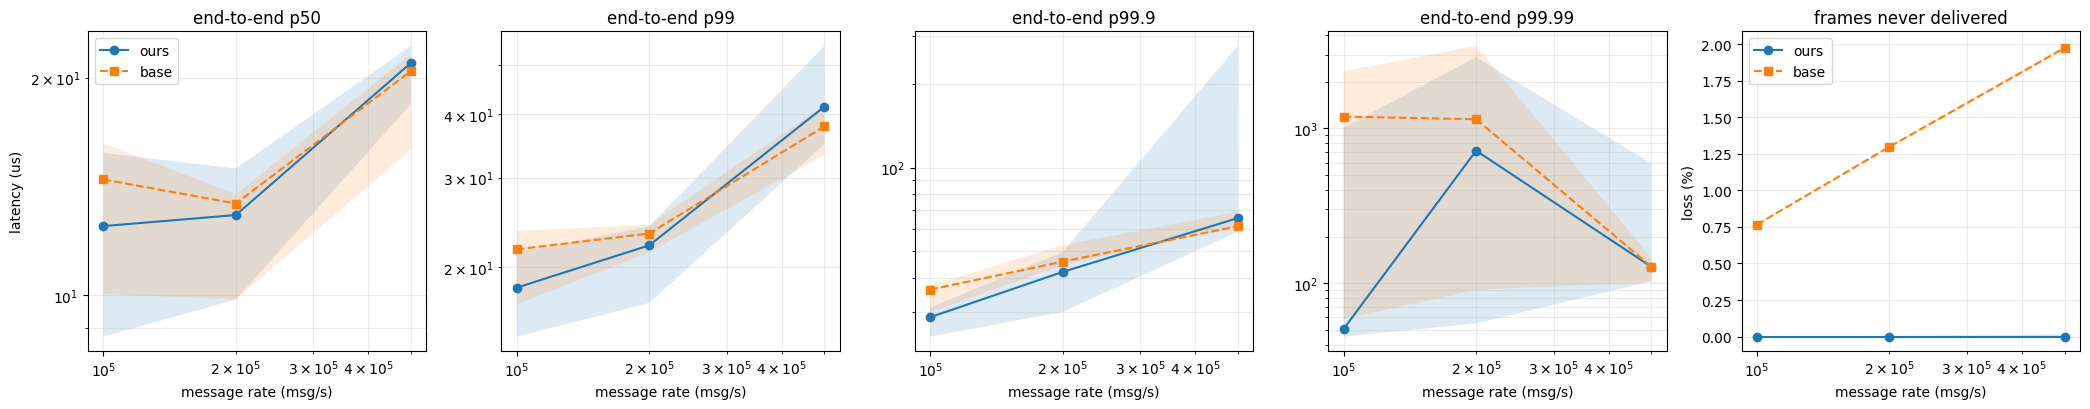

In [4]:
PCTS = [("e2e_p50", "p50"), ("e2e_p99", "p99"), ("e2e_p999", "p99.9"), ("e2e_p9999", "p99.99")]
dirs = sorted(glob.glob("data/sweep_*"), key=lambda d: int(d.rsplit("_", 1)[1]))
rows, loss = defaultdict(lambda: defaultdict(list)), defaultdict(lambda: defaultdict(list))
for d in dirs:
    rate = int(d.rsplit("_", 1)[1])
    for r in load(d):
        for k, _ in PCTS:
            if r.get(k):
                rows[(r["arm"], k)][rate].append(float(r[k]))
        if r.get("loss_pct"):
            loss[r["arm"]][rate].append(float(r["loss_pct"]))
med = lambda v: sorted(v)[len(v) // 2] if len(v) % 2 else 0.5 * sum(sorted(v)[len(v) // 2 - 1:len(v) // 2 + 1])

fig, axes = plt.subplots(1, 5, figsize=(21, 4.2))
style = {"ours": dict(ls="-", marker="o"), "base": dict(ls="--", marker="s")}
for ax, (k, label) in zip(axes, PCTS):
    for arm in ("ours", "base"):
        rs = sorted(rows[(arm, k)])
        ax.fill_between(rs, [min(rows[(arm, k)][r]) / 1e3 for r in rs],
                            [max(rows[(arm, k)][r]) / 1e3 for r in rs], alpha=0.15)
        ax.plot(rs, [med(rows[(arm, k)][r]) / 1e3 for r in rs], label=arm, **style[arm])
    ax.set(xscale="log", yscale="log", title=f"end-to-end {label}", xlabel="message rate (msg/s)")
    ax.grid(True, which="both", alpha=0.25)
axes[0].set_ylabel("latency (us)"); axes[0].legend()
ax = axes[4]
for arm in ("ours", "base"):
    rs = sorted(loss[arm])
    ax.fill_between(rs, [min(loss[arm][r]) for r in rs], [max(loss[arm][r]) for r in rs], alpha=0.15)
    ax.plot(rs, [med(loss[arm][r]) for r in rs], label=arm, **style[arm])
ax.set(xscale="log", title="frames never delivered", xlabel="message rate (msg/s)", ylabel="loss (%)")
ax.grid(True, which="both", alpha=0.25); ax.legend()
fig.tight_layout(); plt.show()

The loss panel separates cleanly at every rate and the bands never approach each other.
The four latency panels overlap everywhere. The rise in the baseline's loss with rate is
what the mechanism predicts: the hole is a fixed *duration* — the time spent in `memset` —
so the fraction of a run it consumes grows with the rate. At 1M msg/s it reached 162,732
datagrams.

## 6. The tail above p99.9 is one recurring event, and it should be counted, not averaged

At p99.99 the numbers stop describing the transport. A single 1-3 ms stall contaminates a
few hundred samples out of two million, which is exactly the p99.99 region, so one event
sets the value. That is why the between-block spread reaches 2-3.8 ms while a clean block
sits at 43-110 us.

The honest statistic is therefore how often a stall lands in a measurement window, not the
median of a number one event decides.

In [5]:
FULL = {"base", "late", "dup_all", "dup_on"}
LEAN = {"ours", "early", "dup_trades", "dup_off"}
tab = defaultdict(lambda: [0, 0])
for f in glob.glob("data/*/blocks.csv"):
    for r in csv.DictReader(open(f)):
        if r["valid"] != "1" or not r.get("e2e_p9999"):
            continue
        cls = "every datagram copied" if r["arm"] in FULL else ("reduced copy stream" if r["arm"] in LEAN else None)
        if cls:
            tab[cls][1] += 1
            tab[cls][0] += float(r["e2e_p9999"]) > 500_000
print("arm-runs whose p99.99 exceeded 500 us, i.e. a stall landed in the window:\n")
for k, (s, n) in sorted(tab.items()):
    print(f"  {k:<24}{s:3d} of {n:3d}   {100*s/n:5.1f}%")
a, na = tab["every datagram copied"]; b, nb = tab["reduced copy stream"]
n, k = na + nb, a + b
tot = comb(n, k)
pr = lambda x: comb(na, x) * comb(nb, k - x) / tot
obs = pr(a)
p = sum(pr(x) for x in range(k + 1) if x <= na and k - x <= nb and pr(x) <= obs * 1.000001)
print(f"\n  Fisher exact p = {p:.3f}")

arm-runs whose p99.99 exceeded 500 us, i.e. a stall landed in the window:

  every datagram copied    23 of  47    48.9%
  reduced copy stream      14 of  54    25.9%

  Fisher exact p = 0.023


Halving the copy stream halves how often the stall appears, which locates it on the
receive path and ties it to datagram rate rather than to elapsed time.

This one is **pooled across every run in this notebook**, which is a weaker construction
than the per-experiment sign tests above: the arms are counterbalanced inside each
experiment, so the rate mix is balanced between the two classes, but the pooling was
decided after seeing the data rather than before. Read it as a strong indication with a
known weakness in how it was assembled, not as a designed result.

The cause itself was not found. What was ruled out, with the counters to support each:

* **The sender.** `send_all` max 656 us with two calls over 100 us in 9.47M datagrams.
* **Consumer scheduling.** `SCHED_FIFO` at priority 80 changed nothing.
* **IPIs and TLB shootdowns.** Over 16 hours the isolated cores recorded 0 TLB shootdowns
  and roughly 3,000 function-call IPIs, about 0.05/s. `stop_machine` was the strongest
  prior and the counters exclude it.
* **Timer ticks.** Local timer interrupts: 66.6M on core 0, 364k on the receiver's core,
  ~700 on the remaining isolated cores. `nohz_full` is working.
* **ENA PPS shaping.** `pps_allowance_exceeded` was sampled every 10 s under load and did
  not move. It *had* incremented earlier, during the 1M msg/s sweep — which is a separate
  and real finding about that rate.
* **Interrupt moderation, THP, systemd timers.** None matched the period; see below.

## 7. Things that were measured and did not work

Reporting these is not modesty. Each was expected to help, and the design that survives is
the one whose failures are known.

| idea | result |
|---|---|
| temporal stagger + sliding-bitmap gate | six blocks, **nothing** resolved on any metric; 130 frames rescued out of 47,543. It was aimed at the `memset` hole, and no redundancy scheme can cross a hole that swallows both copies. |
| ENA interrupt moderation off | 5k/s: 17,030 → 16,963 ns (unchanged). 20k/s: 13,364 → 14,813 ns (worse). The receiver's busy-poll drives NAPI directly and never waits for the interrupt. |
| `IP_TOS` = `IPTOS_LOWDELAY` | +6.6 us at p50 over four runs. Removed. |
| io_uring send backend | median e2e p50 difference −402 ns against a between-block spread of 6,319; sign p=0.625. |
| AF_XDP | not attempted on this bench. The backend's own notes record that this driver refuses `XDP_ZEROCOPY`, leaving `XDP_COPY` through `xsk_generic_xmit`; and section 3 bounds any transmit-side saving at roughly zero. |
| hand-applied clock-offset correction | withdrawn, section 4. |

## 8. Constraints not accounted for

* **Loss was never injected.** The task describes a channel with 0.01-1 % loss. Two hosts
  in one subnet and one placement group lose on the order of 10⁻⁵: 26 datagrams in 9.9M in
  one run, 274 in 9.5M in another. Every loss result here says the transport stopped
  losing frames *to itself*; none of it demonstrates behaviour under the loss the task
  describes. Trade-only redundancy is argued from the format, not from a measurement of it
  working.
* **Fan-out was never measured.** `bench.sh` needs `(cores - 1) / 2` receivers and this
  bench has four cores, so every run here is fan-out 1. Destination rotation is implemented
  in `udp_backend.h` — the baseline sends to peers in a fixed order, so the last peer waits
  behind all the others on every datagram, and its published skew of 11.7 us at ten
  receivers is systematic rather than jitter — but at fan-out 1 the rotation is a no-op and
  **the code is untested**.
* **Multicast is unavailable here.** One send for N receivers is the right shape for
  fan-out, and EC2 VPC does not carry multicast between instances. On a physical LAN it
  would likely dominate every fan-out result in this notebook.
* **1M msg/s could not be measured.** The consumer collected zero samples; the sender was
  emitting 38M datagrams per run at 1.54 frames per datagram, and this is where
  `pps_allowance_exceeded` moved. That is the bench's ceiling, not the transport's.
* **The rate range is narrow**, 100k to 500k, and fan-out is fixed at 1. The judged surface
  is wider than what is covered here.
* **Absolute cross-host latencies are not published**, only within-block differences. The
  clock offset between the hosts is not stable enough to support anything else, and
  section 4 quantifies that rather than asserting it.